# Energy test (two-sample case) use toy 2D Gaussian data

This notebook demonstrates a single threaded **energy-distance two-sample test** for comparing two 2D distributions
The toy data are generated as two Gaussian samples, then the energy statistic is computed, and estimate a **p-value via sample permutations**.


## Energy test (energy distance) — a short story...

The **energy test** is a **nonparametric two-sample test**: given two independent samples

- $(X_1,\dots,X_n \sim P)$ and
- $(Y_1,\dots,Y_m \sim Q)$,

it tests the null hypothesis $(H_0: P = Q)$ against $(H_1: P \neq Q$).

### Intuition
If the two samples come from the **same** distribution, then typical distances

- **between** points drawn from different samples (cross distances) and
- **within** each sample

should be comparable. If the distributions differ (shift, shape, correlation structure, multimodality, …), cross distances tend to increase relative to within-sample distances.

### A common statistic
A widely used (biased, but consistent) estimator of the *energy distance* is

$
E_{n,m} =
\frac{2}{nm} \sum_{i=1}^{n} \sum_{j=1}^{m} \lVert X_i - Y_j \rVert
- \frac{1}{n^2} \sum_{i=1}^{n} \sum_{i'=1}^{n} \lVert X_i - X_{i'} \rVert
- \frac{1}{m^2} \sum_{j=1}^{m} \sum_{j'=1}^{m} \lVert Y_j - Y_{j'} \rVert .
$

- $\lVert\cdot\rVert$ is typically the **Euclidean distance** (here in 2D).
- Larger values of $E_{n,m}$ indicate stronger evidence that $P \neq Q$.

> Note: there is also an *unbiased* version (excluding some diagonal terms / using slightly different normalizations).
> In practice, for permutation p-values, both variants behave similarly; the permutation calibration is the key.

### p-value by permutation (label swapping)
Under $H_0$, the labels “X” and “Y” are **exchangeable**. So we:
1. **pool** all points,
2. repeatedly **shuffle labels** into groups of sizes $n$ and $m$,
3. recompute $E$ for each shuffle,
4. estimate
$
p = \frac{1 + \#\{ E_{perm} \ge E_{obs} \}}{B+1},
$
where $B$ is the number of permutations.

### Practical notes
- **Scaling matters**: if coordinates have very different units/scales, standardize or whiten first.
- **Sensitivity**: the test is sensitive to many alternatives (mean shift, variance change, correlation change, non-Gaussian structure).
- **Complexity**: a straightforward implementation is $O((n+m)^2)$ to build pairwise distances, and then $O(B)$ statistic evaluations.
  Precomputing the pooled distance matrix makes each permutation fast.

### Variants
Sometimes one uses $(\lVert x-y\rVert^{\beta})$ with $(0<\beta<2)$ instead of $(\lVert x-y\rVert)$.



In [73]:
import numpy as np
import matplotlib.pyplot as plt

""" can change seed or keep it fixed """
rng = np.random.default_rng(7)

import time


## 1) Generate synthetic 2D data

- Sample **X**: standard 2D Gaussian  
- Sample **Y**: slightly shifted + correlated 2D Gaussian


In [74]:
n, m = 400, 400

""" X ~ N(0, I) - first sample"""
X = rng.normal(loc=0.0, scale=1.0, size=(n, 2))

""" Y ~ N(mu, Sigma) - second sample with shift and correlation """
mu = np.array([0.35, 0.45])
Sigma = np.array([[1.0, 0.25],
                  [0.25, 0.55]])

L = np.linalg.cholesky(Sigma)
Y = rng.normal(size=(m, 2)) @ L.T + mu

# Test for the same distribution
# Y = rng.normal(loc=0.0, scale=1.0, size=(m, 2))

X.shape, Y.shape


((400, 2), (400, 2))

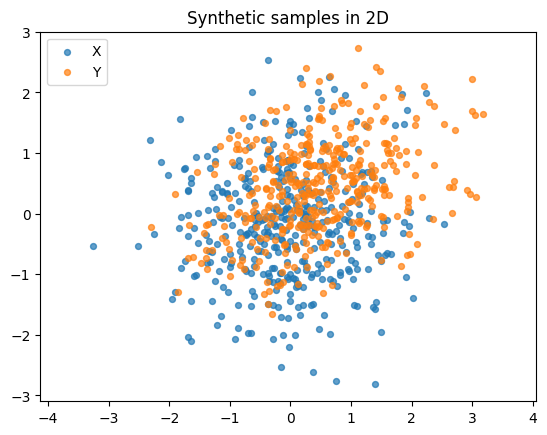

In [75]:
plt.figure()
plt.scatter(X[:,0], X[:,1], s=18, alpha=0.7, label="X")
plt.scatter(Y[:,0], Y[:,1], s=18, alpha=0.7, label="Y")
plt.axis("equal")
plt.title("Synthetic samples in 2D")
plt.legend()
plt.show()


## 2) Energy statistic

We use the (biased) energy statistic:

$
E = 2\,\mathbb{E}\|X-Y\| - \mathbb{E}\|X-X'\| - \mathbb{E}\|Y-Y'\|
$

In practice we replace expectations with **pairwise-distance means**.
(We include the diagonal distances, which are zero; this version is common and works well with permutation p-values.)


## Timing
We use `time.perf_counter()` to measure:
- the **distance-matrix** build time, and
- the **permutation loop** time.


In [76]:
def pairwise_euclidean(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Pairwise Euclidean distances between rows of A and rows of B"""
    diff = A[:, None, :] - B[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2))

def energy_statistic_from_distance_matrix(D: np.ndarray, idx_x: np.ndarray, idx_y: np.ndarray) -> float:
    """Compute energy statistic using a precomputed pooled distance matrix D (N x N)."""
    # cross mean over n*m
    cross = D[np.ix_(idx_x, idx_y)].mean()
    # within means over n*n and m*m (diagonal included, distance=0)
    within_x = D[np.ix_(idx_x, idx_x)].mean()
    within_y = D[np.ix_(idx_y, idx_y)].mean()
    return 2.0 * cross - within_x - within_y

# Precompute pooled distances (O((n+m)^2) time and memory)
Z = np.vstack([X, Y])
D = pairwise_euclidean(Z, Z)

idx_x = np.arange(n)
idx_y = np.arange(n, n+m)

E_obs = energy_statistic_from_distance_matrix(D, idx_x, idx_y)
E_obs


np.float64(0.2909821392150762)

In [77]:
# Precompute pooled distances (O((n+m)^2) time and memory)
Z = np.vstack([X, Y])

t0 = time.perf_counter()
D = pairwise_euclidean(Z, Z)
t1 = time.perf_counter()

print(f"Distance matrix D shape: {D.shape}")
print(f"Distance matrix computation time: {(t1 - t0):.4f} s")
print(f"Approx. distances computed: {D.size:,}  ->  {D.size / (t1 - t0):,.0f} distances/s")

idx_x = np.arange(n)
idx_y = np.arange(n, n+m)

E_obs = energy_statistic_from_distance_matrix(D, idx_x, idx_y)
E_obs


Distance matrix D shape: (800, 800)
Distance matrix computation time: 0.0296 s
Approx. distances computed: 640,000  ->  21,617,244 distances/s


np.float64(0.2909821392150762)

## 3) Permutation test for a p-value

We repeatedly shuffle the pooled indices into two groups of sizes **n** and **m**, recompute \(E\), and estimate:

$
p = \frac{1 + \#\{E_{perm} \ge E_{obs}\}}{B + 1}
$

This is a standard finite-sample correction.


In [78]:
def energy_test_pvalue(D: np.ndarray, n: int, m: int, B: int = 2000, seed: int = 123) -> tuple[float, np.ndarray, float, float]:
    """Return (p_value, E_perm, E_obs, permutation_time_seconds)."""
    rng = np.random.default_rng(seed)
    N = n + m
    all_idx = np.arange(N)

    # observed
    idx_x = np.arange(n)
    idx_y = np.arange(n, N)
    E_obs = energy_statistic_from_distance_matrix(D, idx_x, idx_y)

    # permutations
    E_perm = np.empty(B, dtype=float)
    t0 = time.perf_counter()
    for b in range(B):
        perm = rng.permutation(all_idx)
        px = perm[:n]
        py = perm[n:]
        E_perm[b] = energy_statistic_from_distance_matrix(D, px, py)
    t1 = time.perf_counter()

    perm_time = t1 - t0
    p = (1.0 + np.sum(E_perm >= E_obs)) / (B + 1.0)
    return p, E_perm, E_obs, perm_time

B = 1000
p_value, E_perm, E_obs, perm_time = energy_test_pvalue(D, n, m, B=B, seed=2026)

print(f"Observed energy statistic: {E_obs:.6f}")
print(f"Permutation p-value (B={B}): {p_value:.6f}")
print(f"Permutation loop time: {perm_time:.4f} s  ->  {B/perm_time:,.1f} permutations/s")


Observed energy statistic: 0.290982
Permutation p-value (B=1000): 0.000999
Permutation loop time: 4.0143 s  ->  249.1 permutations/s


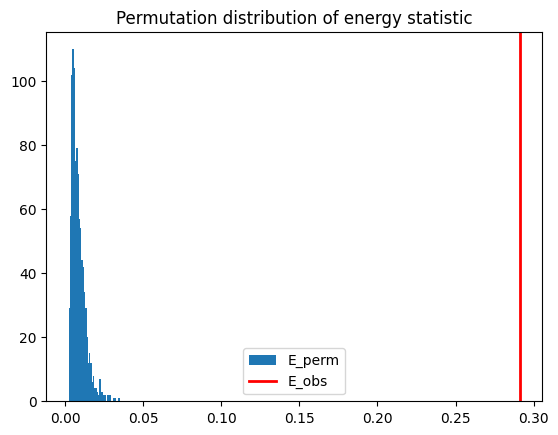

In [79]:
plt.figure()
plt.hist(E_perm, bins=40, label="E_perm")
plt.axvline(E_obs, linewidth=2, label="E_obs", color="red")
plt.title("Permutation distribution of energy statistic")
plt.legend()
plt.show()
